In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def leer_dosis_phits_tdeposit(filename):
    posicion = []
    dosis = []
    error_relativo = []
    leyendo_tabla = False
    eje = None

    with open(filename, "r", encoding="utf-8", errors="ignore") as archivo:
        for linea in archivo:
            texto = linea.strip()

            if texto.startswith("#  z-lower") and "proton" in texto:
                eje = "z"
                leyendo_tabla = True
                continue

            if texto.startswith("#  r-lower") and "proton" in texto:
                eje = "r"
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                partes = texto.replace("D", "E").split()

                if len(partes) != 4:
                    if dosis:
                        break
                    continue

                try:
                    limite_inferior = float(partes[0])
                    limite_superior = float(partes[1])
                    dosis_proton = float(partes[2])
                    error = float(partes[3])
                except ValueError:
                    if dosis:
                        break
                    continue

                posicion.append((limite_inferior + limite_superior) / 2)
                dosis.append(dosis_proton)
                error_relativo.append(error)

    return (
        np.array(posicion),
        np.array(dosis),
        np.array(error_relativo),
        eje
    )

In [3]:
carpeta_out = Path("../out")
file_path = carpeta_out / "bragg_pouch_z.out"

z, data_dosis, error_relativo, eje = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores:", len(data_dosis))
print("Primeras posiciones:", z[:5])
print("Primeras dosis:", data_dosis[:5])

Cantidad de valores: 200
Primeras posiciones: [97.005 97.015 97.025 97.035 97.045]
Primeras dosis: [0.23539 0.2345  0.23491 0.23413 0.23297]


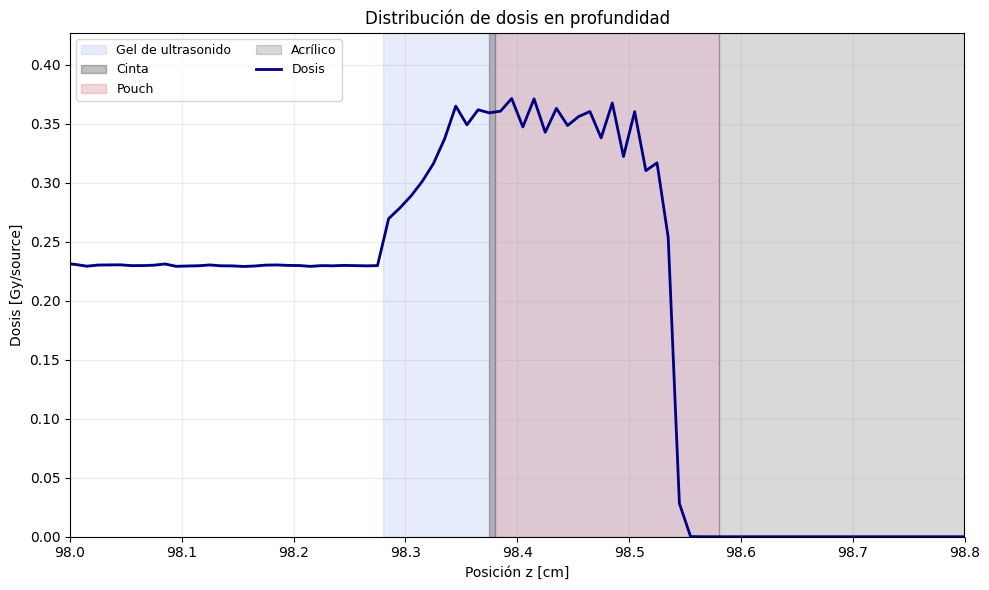

Dosis mínima: 0.000000 Gy/source
Dosis máxima: 0.371320 Gy/source
Posición del máximo: 98.3950 cm
Dosis media: 0.192109 Gy/source
Error relativo medio: 0.27 %


In [4]:
error_absoluto = data_dosis * error_relativo
dosis_media = np.mean(data_dosis)
dosis_maxima = np.max(data_dosis)
z_maximo = z[np.argmax(data_dosis)]

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvspan(98.28, 98.58, color="royalblue", alpha=0.12, label="Gel de ultrasonido")
ax.axvspan(98.375, 98.38, color="black", alpha=0.25, label="Cinta")
ax.axvspan(98.38, 98.58, color="firebrick", alpha=0.18, label="Pouch")
ax.axvspan(98.58, 99.01, color="black", alpha=0.15, label="Acrílico")

ax.plot(
    z,
    data_dosis,
    color="navy",
    linewidth=2,
    label="Dosis"
)

ax.fill_between(
    z,
    data_dosis - error_absoluto,
    data_dosis + error_absoluto,
    color="cornflowerblue",
    alpha=0.3
)

ax.set_xlim(98,98.8)
ax.set_ylim(0, dosis_maxima * 1.15)

ax.set_xlabel("Posición z [cm]")
ax.set_ylabel("Dosis [Gy/source]")
ax.set_title("Distribución de dosis en profundidad")

ax.grid(True, alpha=0.25)
ax.legend(fontsize=9, ncols=2)
fig.tight_layout()

plt.show()

print(f"Dosis mínima: {data_dosis.min():.6f} Gy/source")
print(f"Dosis máxima: {dosis_maxima:.6f} Gy/source")
print(f"Posición del máximo: {z_maximo:.4f} cm")
print(f"Dosis media: {dosis_media:.6f} Gy/source")
print(f"Error relativo medio: {100*np.mean(error_relativo):.2f} %")

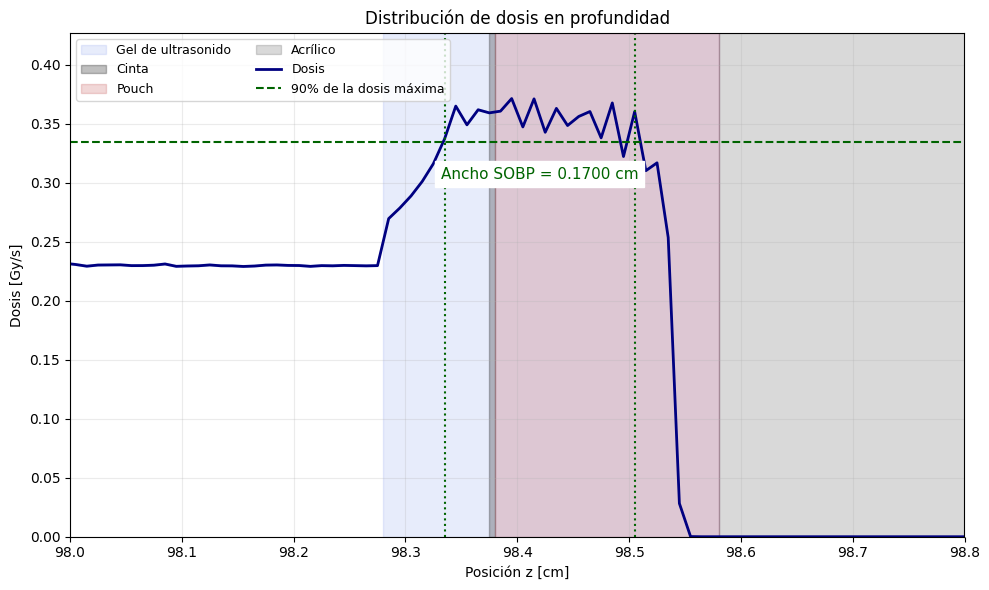

Dosis mínima: 0.000000 Gy/source
Dosis máxima: 0.371320 Gy/source
Posición del máximo: 98.3950 cm
Dosis media: 0.192109 Gy/source
Error relativo medio: 0.27 %

----- SOBP -----
Nivel SOBP (90%): 0.334188 Gy/source
Inicio del SOBP: 98.3350 cm
Fin del SOBP: 98.5050 cm
Ancho del SOBP: 0.1700 cm


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CÁLCULOS
# ============================================================

error_absoluto = data_dosis * error_relativo

dosis_media = np.mean(data_dosis)

dosis_maxima = np.max(data_dosis)

z_maximo = z[np.argmax(data_dosis)]

# ============================================================
# ANCHO DEL SOBP
# ============================================================

# Nivel utilizado para definir el SOBP
nivel_sobp = 0.90 * dosis_maxima

# Puntos donde la dosis está por encima del 90% de la dosis máxima
indices_sobp = np.where(data_dosis >= nivel_sobp)[0]

if len(indices_sobp) > 0:

    # Primer y último punto dentro del SOBP
    i_inicio = indices_sobp[0]
    i_fin = indices_sobp[-1]

    z_inicio_sobp = z[i_inicio]
    z_fin_sobp = z[i_fin]

    ancho_sobp = z_fin_sobp - z_inicio_sobp

else:

    z_inicio_sobp = np.nan
    z_fin_sobp = np.nan
    ancho_sobp = np.nan


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# ------------------------------------------------------------
# Materiales
# ------------------------------------------------------------

ax.axvspan(
    98.28, 98.58,
    color="royalblue",
    alpha=0.12,
    label="Gel de ultrasonido"
)

ax.axvspan(
    98.375, 98.38,
    color="black",
    alpha=0.25,
    label="Cinta"
)

ax.axvspan(
    98.38, 98.58,
    color="firebrick",
    alpha=0.18,
    label="Pouch"
)

ax.axvspan(
    98.58, 99.01,
    color="black",
    alpha=0.15,
    label="Acrílico"
)

# ------------------------------------------------------------
# Dosis
# ------------------------------------------------------------

ax.plot(
    z,
    data_dosis,
    color="navy",
    linewidth=2,
    label="Dosis"
)

# Error

ax.fill_between(
    z,
    data_dosis - error_absoluto,
    data_dosis + error_absoluto,
    color="cornflowerblue",
    alpha=0.3
)

# ------------------------------------------------------------
# Nivel del 90% para definir el SOBP
# ------------------------------------------------------------

ax.axhline(
    nivel_sobp,
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
    label="90% de la dosis máxima"
)

# ------------------------------------------------------------
# Límites del SOBP
# ------------------------------------------------------------

if not np.isnan(ancho_sobp):

    ax.axvline(
        z_inicio_sobp,
        color="darkgreen",
        linestyle=":",
        linewidth=1.5
    )

    ax.axvline(
        z_fin_sobp,
        color="darkgreen",
        linestyle=":",
        linewidth=1.5
    )

    # Flecha indicando el ancho
    y_flecha = nivel_sobp * 0.9

    ax.annotate(
        "",
        xy=(z_fin_sobp, y_flecha),
        xytext=(z_inicio_sobp, y_flecha),
        arrowprops=dict(
            arrowstyle="<->",
            color="darkgreen",
            linewidth=2
        )
    )

    ax.text(
        (z_inicio_sobp + z_fin_sobp) / 2,
        y_flecha,
        f"Ancho SOBP = {ancho_sobp:.4f} cm",
        ha="center",
        va="bottom",
        color="darkgreen",
        fontsize=11,
        backgroundcolor="white"
    )

# ============================================================
# CONFIGURACIÓN
# ============================================================

ax.set_xlim(98, 98.8)

ax.set_ylim(
    0,
    dosis_maxima * 1.15
)

ax.set_xlabel("Posición z [cm]")

ax.set_ylabel("Dosis [Gy/s]")

ax.set_title("Distribución de dosis en profundidad")

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    fontsize=9,
    ncols=2
)

fig.tight_layout()

plt.show()


# ============================================================
# RESULTADOS
# ============================================================

print(f"Dosis mínima: {data_dosis.min():.6f} Gy/source")

print(f"Dosis máxima: {dosis_maxima:.6f} Gy/source")

print(f"Posición del máximo: {z_maximo:.4f} cm")

print(f"Dosis media: {dosis_media:.6f} Gy/source")

print(f"Error relativo medio: {100*np.mean(error_relativo):.2f} %")

print()
print("----- SOBP -----")

print(f"Nivel SOBP (90%): {nivel_sobp:.6f} Gy/source")

print(f"Inicio del SOBP: {z_inicio_sobp:.4f} cm")

print(f"Fin del SOBP: {z_fin_sobp:.4f} cm")

print(f"Ancho del SOBP: {ancho_sobp:.4f} cm")

### Le aplicamos un suavizado

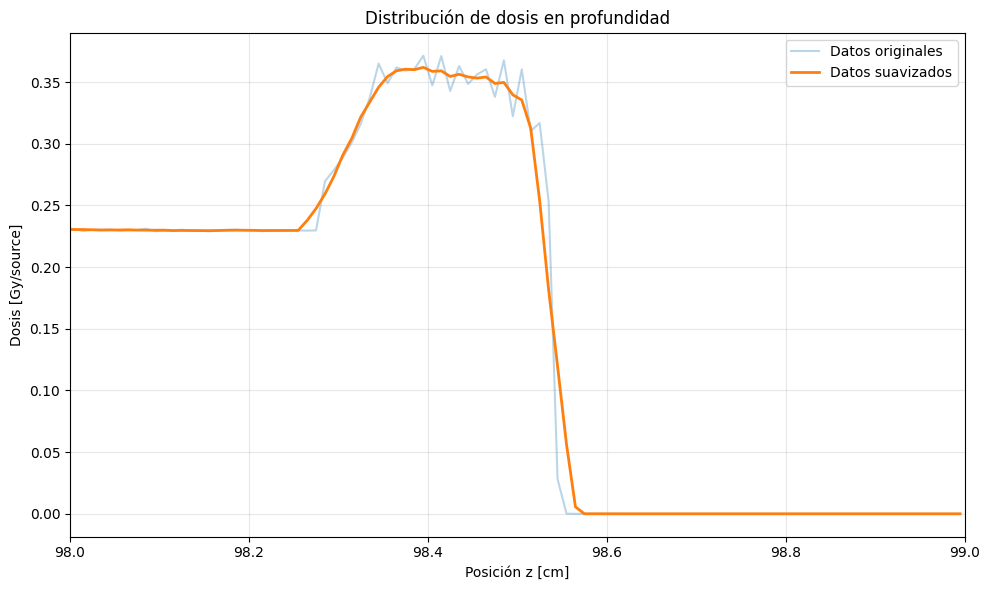

In [6]:
from scipy.signal import savgol_filter

dosis_suavizada = savgol_filter(data_dosis, 5, 1)

plt.figure(figsize=(10, 6))
plt.plot(z, data_dosis, alpha=0.3, label="Datos originales")
plt.plot(z, dosis_suavizada, linewidth=2, label="Datos suavizados")
plt.xlim(98, 99)

plt.xlabel("Posición z [cm]")
plt.ylabel("Dosis [Gy/source]")
plt.title("Distribución de dosis en profundidad")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Dosis Radial

In [7]:
file_path_r = carpeta_out / "bragg_pouch_r.out"

r, dosis_radial, error_relativo_r, eje = leer_dosis_phits_tdeposit(file_path_r)

print("Eje leído:", eje)
print("Cantidad de valores:", len(dosis_radial))
print("Primeros radios:", r[:5])
print("Primeras dosis:", dosis_radial[:5])

Eje leído: r
Cantidad de valores: 60
Primeros radios: [0.0141665 0.0425    0.0708335 0.099165  0.1275   ]
Primeras dosis: [0.28586 0.27422 0.27738 0.27465 0.2778 ]


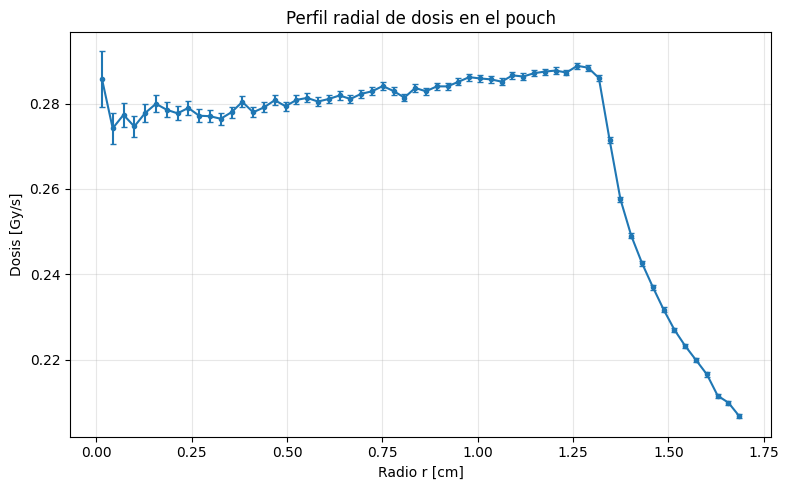

In [10]:
error_absoluto_r = dosis_radial * error_relativo_r

plt.figure(figsize=(8, 5))

plt.errorbar(
    r,
    dosis_radial,
    yerr=error_absoluto_r,
    fmt="o-",
    markersize=3,
    capsize=2
)

plt.xlabel("Radio r [cm]")
plt.ylabel("Dosis [Gy/s]")
plt.title("Perfil radial de dosis en el pouch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
dosis_minima = np.min(dosis_radial)
dosis_maxima = np.max(dosis_radial)
dosis_media = np.mean(dosis_radial)
mediana = np.median(dosis_radial)
desvio = np.std(dosis_radial)
cv = 100 * desvio / dosis_media

r_minimo = r[np.argmin(dosis_radial)]
r_maximo = r[np.argmax(dosis_radial)]

print(f"Dosis mínima: {dosis_minima:.6f} Gy/source")
print(f"Posición del mínimo: {r_minimo:.4f} cm")
print(f"Dosis máxima: {dosis_maxima:.6f} Gy/source")
print(f"Posición del máximo: {r_maximo:.4f} cm")
print(f"Dosis media: {dosis_media:.6f} Gy/source")
print(f"Mediana: {mediana:.6f} Gy/source")
print(f"Desviación estándar: {desvio:.6f} Gy/source")
print(f"Coeficiente de variación: {cv:.2f} %")
print(f"Error relativo medio: {100*np.mean(error_relativo_r):.2f} %")

Dosis mínima: 0.206750 Gy/source
Posición del mínimo: 1.6858 cm
Dosis máxima: 0.288860 Gy/source
Posición del máximo: 1.2609 cm
Dosis media: 0.271084 Gy/source
Mediana: 0.280650 Gy/source
Desviación estándar: 0.023056 Gy/source
Coeficiente de variación: 8.51 %
Error relativo medio: 0.41 %
